In [29]:

import numpy as np
from tqdm import trange
from pathlib import Path
import matplotlib.pyplot as plt
import time
import sys
import pandas as pd
import scipy
import sympy as sp
from scipy.interpolate import interp1d

import os
import sklearn.gaussian_process as gp
from scipy import stats


sys.path.append('../..')
sys.path.append('../GP_regr')
import plot_settings
import importlib
#import multi_exp_log
import SR_lib

import GP



from IPython.display import display, Math

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(plot_settings)
    importlib.reload(SR_lib)
    importlib.reload(GP)

import_reload()
GP_FIT = GP.GP_process()

# Importing data

In [30]:
RUN_ID = 'test1'
SAVE  = True
SELECTION = 'best'
DT = 1
Q0 = 17921.57581 
ITS = int(2e1)

# check if run_id exists, if not create it
if os.path.exists(f'saved_sr_models/{RUN_ID}/model_UE_{RUN_ID}.csv'):
    raise ValueError(f'Run ID {RUN_ID} already exists. Please choose a different one.')

ValueError: Run ID test1 already exists. Please choose a different one.

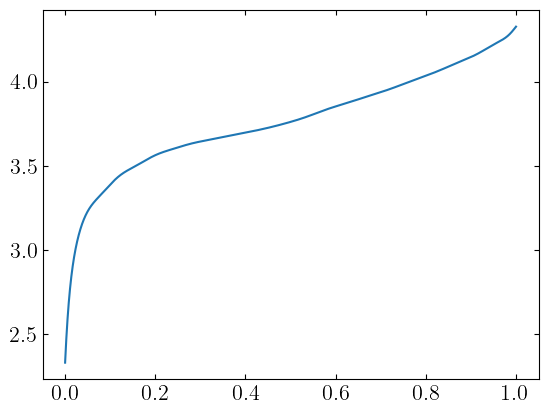

In [ ]:
soc = np.linspace(0,1.0,int(1e4))
Ue = GP.soc_to_Ue(soc,GP_FIT) 
#t = np.linspace(0,3600,int(1e4))
plt.plot(soc, Ue)

In [ ]:
X_train = soc.reshape(-1,1)
Y_train = Ue.reshape(-1,1)

# $U_{eq} = f_U(\mathrm{SOC})$

Variable names for element Ue: ['soc']
Running symbolic regression for element Ue with run_id Ueq_test1...
Settings: iterations=20, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.09615142
Equation: 3.7620351

Model 1: Complexity=3, Loss=0.010167053
Equation: soc + 3.261545

Model 2: Complexity=4, Loss=0.009430214
Equation: sqrt(soc) + 3.0933895

Model 3: Complexity=6, Loss=0.0050637587
Equation: (sqrt(soc) * 1.2765094) - -2.9105246

Model 4: Complexity=7, Loss=0.003988507
Equation: sqrt(exp(sqrt(sqrt(soc)))) * 2.5146072

Model 5: Complexity=9, Loss=0.003884456
Equation: tan(soc ^ 0.2201592) + 2.6440516

Model 6: Complexity=10, Loss=0.0024257316
Equation: (sqrt(sqrt(tan(soc))) - -1.5206717) * 1.5988543

Model 7: Complexity=11, Loss=0.0017400349
Equation: (sqrt(sqrt(cube(cube(soc)) + soc)) - -1.509323) * 1.6127207

Model 8: Complexity=14, Loss=0.0016289881
Equation: (sqrt(sqrt(sin(soc) + cube(cube(soc)))) - -1.4372013) * 1.6718084

Model 9: Complexity=16, Loss=0.0016053533
Equation: (sqrt(sqrt(cube(cube(soc)) + sin(soc / 0.95131016))) - -1.4368163) * 1.6662495

Model 10: Complexity=17, Loss=0.0015555919
Equation: (sqrt(sqrt(sin(soc) 

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: sqrt(sin(sqrt(soc)) + sqrt(sin(soc**9))) + sin((soc**3 - soc**(3*soc))**3) + 2.9662158
Loss: 0.0005417887
Best model complexity: 29


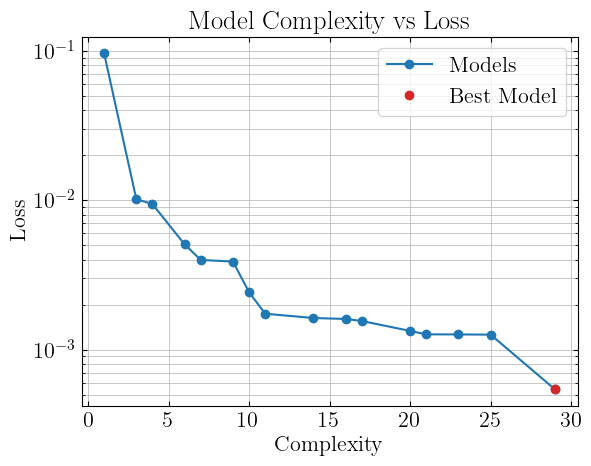

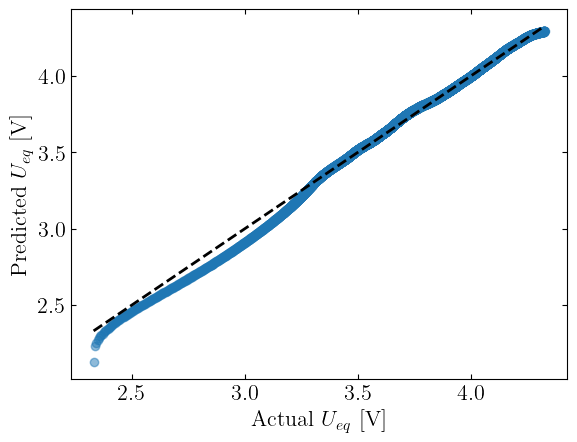

In [ ]:
import_reload()
model_Ue = SR_lib.run_symbolic_regression(X_train, Y_train, model = None,run_id = f'Ueq_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'Ue')
df_model_Ue = model_Ue.equations_
SR_lib.print_models(df_model_Ue)
SR_lib.print_best_model(model_Ue)
SR_lib.pareto_plot(model_Ue)
SR_lib.parity_plot_Ue(model_Ue, Y_train, X_train, colors=colors, data_set='train')

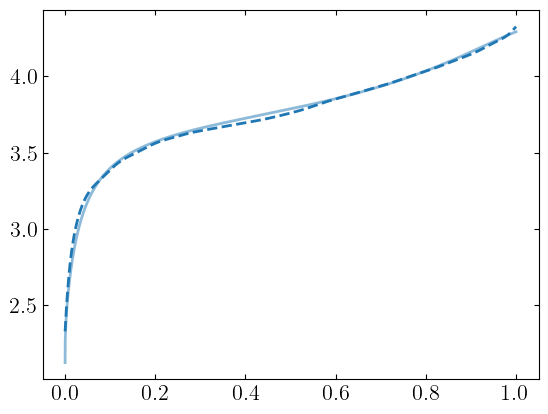

In [ ]:
plt.plot(soc, model_Ue.predict(X_train), color=colors[0], alpha = 0.5, label = 'SR fit', lw = 2)
plt.plot(soc, Ue, color = colors[0],ls = '--', lw = 2, label = 'GP fit')

In [ ]:
if SAVE:
    SR_lib.save_expressions(df_model_Ue,  f'Ue_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_Ue.get_best(), f'Ue_best_{RUN_ID}', run_id = RUN_ID)
    
    #save_expressions(df_model_R1, f'R1_{RUN_ID}')
    #save_expressions(df_model_C1, f'C1_{RUN_ID}')